In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yqCKO9mYyTaK6PMXiTdo")
project = rf.workspace("detelsijalanrusak").project("road-damage-l1ju7-wbbwq")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 7.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 80.3 MB/s eta 0:00:00:00:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-damage-1 in yolov8:: 100%|██████████| 13526/13526 [00:01<00:00, 11841.31it/s]


In [2]:
!pip install -q ultralytics ensemble-boxes opencv-python matplotlib pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.6 MB/s eta 0:00:00a 0:00:01


# 🛠️ Dataset Configuration & Path Verification

In [3]:
import yaml
from pathlib import Path


DATASET_ROOT = Path("/kaggle/working/road-damage-1")

data_yaml_path = DATASET_ROOT / "data.yaml"

with open(data_yaml_path, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(DATASET_ROOT)
data_cfg["train"] = "train/images"
data_cfg["val"] = "valid/images" if (DATASET_ROOT / "valid").exists() else "val/images"
if (DATASET_ROOT / "test").exists():
    data_cfg["test"] = "test/images"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, allow_unicode=True)

print("Number of items (nc):", data_cfg.get("nc"))
print("items:", data_cfg.get("names"))
print("\nFinal content of data.yaml:")
print(yaml.safe_dump(data_cfg, allow_unicode=True))

DATA_YAML = str(data_yaml_path)

Number of items (nc): 7
items: ['alligator', 'block', 'crack', 'edge', 'longitudinal', 'pothole', 'transverse']

Final content of data.yaml:
names:
- alligator
- block
- crack
- edge
- longitudinal
- pothole
- transverse
nc: 7
path: /kaggle/working/road-damage-1
roboflow:
  license: CC BY 4.0
  project: road-damage-l1ju7-wbbwq
  url: https://universe.roboflow.com/detelsijalanrusak/road-damage-l1ju7-wbbwq/dataset/1
  version: 1
  workspace: detelsijalanrusak
test: test/images
train: train/images
val: valid/images



# 3) Common functions for metrics

In [4]:
%%writefile /kaggle/working/metrics_utils.py
"""Shared functions: model size, complexity, and actual IoU matching."""
from pathlib import Path
import numpy as np
import torch
from torchvision.ops import box_iou


def get_model_size_mb(weights_path) -> float:
    p = Path(weights_path)
    if not p.exists():
        return float("nan")
    return round(p.stat().st_size / (1024 * 1024), 2)


def get_model_complexity(model) -> dict:
    """`model.info()` returns a tuple only if `verbose=True` (Ultralytics documentation)."""
    try:
        n_layers, n_params, n_grad, flops = model.info(verbose=True)
        return {"params_M": round(n_params / 1e6, 2),
                "gflops": round(flops, 2) if flops else None}
    except Exception:
        try:
            n_params = sum(p.numel() for p in model.model.parameters())
            return {"params_M": round(n_params / 1e6, 2), "gflops": None}
        except Exception:
            return {"params_M": None, "gflops": None}


def load_yolo_labels(label_path: Path, img_w: int, img_h: int):
    if not label_path.exists():
        return torch.empty((0, 4)), torch.empty((0,), dtype=torch.long)
    boxes, cls = [], []
    for line in label_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        c, cx, cy, w, h = map(float, line.split()[:5])
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h
        boxes.append([x1, y1, x2, y2])
        cls.append(int(c))
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(cls, dtype=torch.long)


def match_predictions_to_gt(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor):
   
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return []
    iou_matrix = box_iou(pred_boxes, gt_boxes)
    used_gt = set()
    matched = []
    for p_idx in range(iou_matrix.shape[0]):
        row = iou_matrix[p_idx].clone()
        for g in used_gt:
            row[g] = -1
        best_gt = int(torch.argmax(row))
        best_iou = float(row[best_gt])
        if best_iou <= 0:
            continue
        used_gt.add(best_gt)
        matched.append(best_iou)
    return matched


def compute_mean_iou(model, images_dir: Path, labels_dir: Path, conf: float = 0.25,
                      max_images=None) -> dict:
    images_dir, labels_dir = Path(images_dir), Path(labels_dir)
    image_paths = sorted(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")))
    if max_images:
        image_paths = image_paths[:max_images]

    all_ious = []
    for img_path in image_paths:
        result = model.predict(str(img_path), conf=conf, verbose=False)[0]
        h, w = result.orig_shape
        gt_boxes, _ = load_yolo_labels(labels_dir / (img_path.stem + ".txt"), w, h)
        pred_boxes = result.boxes.xyxy.cpu()
        all_ious.extend(match_predictions_to_gt(pred_boxes, gt_boxes))

    if not all_ious:
        return {"mean_iou": float("nan"), "median_iou": float("nan"), "n_matches": 0}
    arr = np.array(all_ious)
    return {"mean_iou": round(float(arr.mean()), 4),
            "median_iou": round(float(np.median(arr)), 4),
            "n_matches": len(arr)}


def add_deployment_efficiency(df, w_acc=0.5, w_speed=0.3, w_size=0.2):
   
    df = df.copy()
    max_map = df["mAP50-95"].max() or 1e-9
    max_fps = df["FPS"].max() or 1e-9
    min_size = df["model_size_MB"].min() or 1e-9

    df["acc_score"] = df["mAP50-95"] / max_map
    df["speed_score"] = df["FPS"] / max_fps
    df["size_score"] = min_size / df["model_size_MB"]

    df["deployment_efficiency"] = (
        w_acc * df["acc_score"] + w_speed * df["speed_score"] + w_size * df["size_score"]
    ).round(4)
    return df.drop(columns=["acc_score", "speed_score", "size_score"])


Writing /kaggle/working/metrics_utils.py


In [5]:
import sys
sys.path.insert(0, "/kaggle/working")
from metrics_utils import (
    get_model_size_mb, get_model_complexity, load_yolo_labels,
    match_predictions_to_gt, compute_mean_iou, add_deployment_efficiency,
)
print("metrics_utils was loaded successfully.")

metrics_utils was loaded successfully.


## 4) Comparison Settings

In [6]:
import os
import time
import shutil
import yaml
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

MODELS = ["yolov8m.pt"]           
IMG_SIZE = 768                     
FINAL_EPOCHS = 100               
PATIENCE_EARLY_STOP = 20       

BASELINE_EPOCHS = 0               
TUNE_ITERATIONS = 0                
TUNE_EPOCHS = 0
TUNE_IMG_SIZE = 640

IOU_SAMPLE = 80                     
SELECT_BY = "deployment_efficiency"
W_ACC, W_SPEED, W_SIZE = 0.5, 0.3, 0.2

TRAIN_PROJECT = "/kaggle/working/runs/train_compare"
TUNE_PROJECT = "/kaggle/working/runs/tune_compare"
RESULTS_DIR = Path("/kaggle/working/results")
BACKUP_DIR = Path("/kaggle/working/checkpoint_backup")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 5) Pipeline Functions

In [9]:
DEFAULT_HYP = dict(
    optimizer="AdamW",
    lr0=0.0012, lrf=0.01, momentum=0.937, weight_decay=0.0005,
    warmup_epochs=5.0, cos_lr=True,

    box=11.0,           
    cls=0.35,
    dfl=1.8,            
    label_smoothing=0.0,

    mosaic=1.0,
    mixup=0.08,
    copy_paste=0.15,
    degrees=5.0,
    translate=0.10,
    scale=0.75,
    shear=1.0,
    perspective=0.0002,
    hsv_h=0.012, hsv_s=0.55, hsv_v=0.35,
    fliplr=0.5, flipud=0.0,

    close_mosaic=25,
    multi_scale=False, 
)

def resolve_val_dirs(data_yaml: str):
    with open(data_yaml, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    root = Path(cfg["path"])
    images_dir = root / cfg["val"]
    labels_dir = Path(str(images_dir).replace("images", "labels"))
    return images_dir, labels_dir

def train_final(model_name, data_yaml, epochs, imgsz, project):
    print(f"[Train] Starting optimized training for {model_name}...")
    model = YOLO(model_name)
    model.train(
        data=data_yaml, 
        epochs=epochs, 
        imgsz=imgsz,
        batch=8,                        
        cache=False,                   
        patience=PATIENCE_EARLY_STOP,   
        amp=True, 
        seed=42, 
        plots=True,
        project=project, 
        name=model_name.replace(".pt", ""), 
        exist_ok=True,
        **DEFAULT_HYP,
    )
    return model

def evaluate_model(model, model_name, data_yaml, imgsz, weights_path, iou_sample, conf_for_iou=0.25):
    metrics = model.val(data=data_yaml, imgsz=imgsz, split="val", conf=0.001)
    map50 = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)
    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)

    infer_ms = float(metrics.speed.get("inference", 0.0))
    fps = round(1000.0 / infer_ms, 1) if infer_ms > 0 else float("nan")

    size_mb = get_model_size_mb(weights_path)
    complexity = get_model_complexity(model)

    images_dir, labels_dir = resolve_val_dirs(data_yaml)
    iou_stats = compute_mean_iou(model, images_dir, labels_dir, conf=conf_for_iou, max_images=iou_sample)

    return {
        "model": model_name,
        "mAP50": round(map50, 4),
        "mAP50-95": round(map50_95, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "mean_IoU": iou_stats["mean_iou"],
        "median_IoU": iou_stats["median_iou"],
        "inference_ms": round(infer_ms, 2),
        "FPS": fps,
        "model_size_MB": size_mb,
        "params_M": complexity["params_M"],
        "GFLOPs": complexity["gflops"],
    }

# 6) Running on multiple models

In [11]:
rows = []
for model_name in MODELS:
    print(f"\n{'='*72}\n Processing Model: {model_name}\n{'='*72}")

    t0 = time.time()
    model = train_final(model_name, DATA_YAML, FINAL_EPOCHS, IMG_SIZE, TRAIN_PROJECT)
    train_minutes = round((time.time() - t0) / 60, 1)

    weights_path = Path(TRAIN_PROJECT) / model_name.replace(".pt", "") / "weights" / "best.pt"
    best_model = YOLO(str(weights_path)) if weights_path.exists() else model

    row = evaluate_model(best_model, model_name, DATA_YAML, IMG_SIZE, weights_path, IOU_SAMPLE)
    row["train_minutes"] = train_minutes
    row["weights_path"] = str(weights_path)
    rows.append(row)

    if weights_path.exists():
        shutil.copy(weights_path, BACKUP_DIR / f"{model_name.replace('.pt','')}_best.pt")

    print(f"[Done] {model_name} -> mAP50={row['mAP50']}  mAP50-95={row['mAP50-95']}  "
          f"P={row['precision']}  R={row['recall']}  IoU={row['mean_IoU']}  "
          f"FPS={row['FPS']}  size={row['model_size_MB']}MB")

df = pd.DataFrame(rows)
df = add_deployment_efficiency(df, W_ACC, W_SPEED, W_SIZE)
df = df.sort_values(SELECT_BY, ascending=False).reset_index(drop=True)
df.to_csv(RESULTS_DIR / "comparison_table.csv", index=False)

print("\n--- Pipeline Executed Successfully ---")


 Processing Model: yolov8m.pt
[Train] Starting optimized training for yolov8m.pt...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=11.0, cache=False, cfg=None, classes=None, close_mosaic=25, cls=0.35, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/road-damage-1/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.8, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.012, hsv_s=0.55, hsv_v=0.35, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0012, lrf

# 7) Comparative Charts

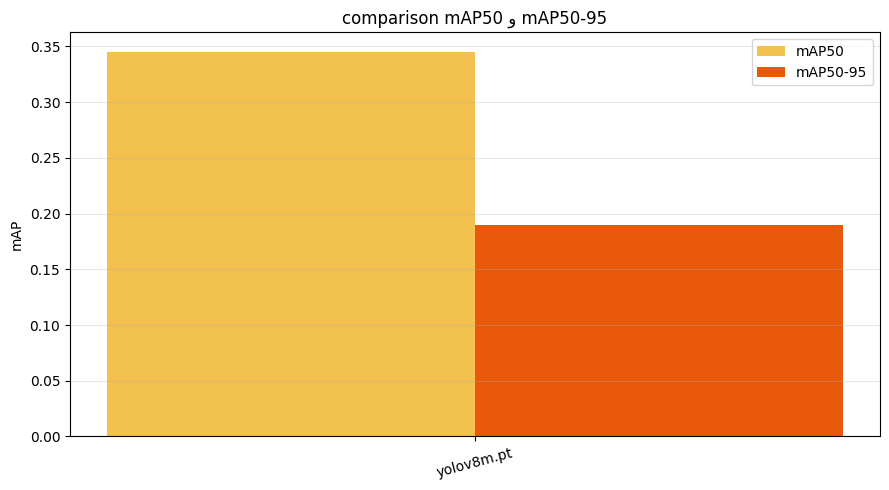

In [12]:
import matplotlib.pyplot as plt

x = range(len(df))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - 0.18 for i in x], df["mAP50"], width=0.36, label="mAP50", color="#F2C14E")
ax.bar([i + 0.18 for i in x], df["mAP50-95"], width=0.36, label="mAP50-95", color="#E8590C")
ax.set_xticks(list(x)); ax.set_xticklabels(df["model"], rotation=15)
ax.set_ylabel("mAP"); ax.set_title("comparison mAP50 و mAP50-95"); ax.legend(); ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); fig.savefig(RESULTS_DIR / "comparison_map_chart.png", dpi=150); plt.show()


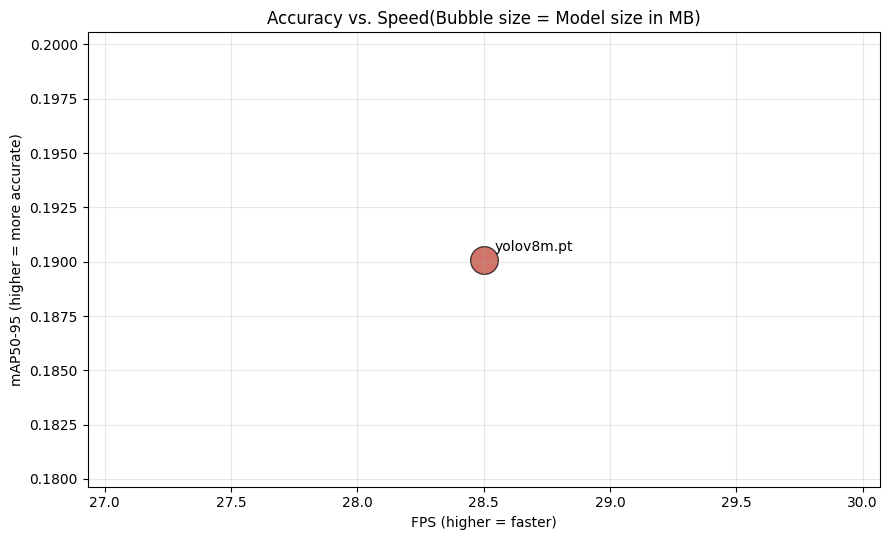

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sizes = (df["model_size_MB"].astype(float) * 8).clip(lower=40)
ax.scatter(df["FPS"], df["mAP50-95"], s=sizes, color="#C0392B", alpha=0.7, edgecolor="black")
for _, r in df.iterrows():
    ax.annotate(r["model"], (r["FPS"], r["mAP50-95"]), textcoords="offset points", xytext=(8, 6))
ax.set_xlabel("FPS (higher = faster)"); ax.set_ylabel("mAP50-95 (higher = more accurate)")
ax.set_title("Accuracy vs. Speed(Bubble size = Model size in MB)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS_DIR / "comparison_speed_vs_accuracy.png", dpi=150); plt.show()


In [14]:
from IPython.display import Markdown, display

best_map = df.loc[df["mAP50-95"].idxmax()]
best_fps = df.loc[df["FPS"].idxmax()]
best_eff = df.loc[df["deployment_efficiency"].idxmax()]
smallest = df.loc[df["model_size_MB"].idxmin()]

report = f"""
### Key Highlights

- **Highest Accuracy (mAP50-95)**: `{best_map['model']}` with a value of {best_map['mAP50-95']:.3f}
  (mAP50={best_map['mAP50']:.3f}, mean IoU={best_map['mean_IoU']:.3f}).
  Suitable when accuracy is the absolute priority over speed.
- **Fastest Model**: `{best_fps['model']}` at {best_fps['FPS']} FPS
  (inference time: {best_fps['inference_ms']} ms). A better choice for real-time video.
- **Smallest Size**: `{smallest['model']}` at {smallest['model_size_MB']} MB —
  Best suited for edge/mobile deployment.
- **Best Overall Deployment Efficiency**: `{best_eff['model']}` with a score of
  {best_eff['deployment_efficiency']:.3f} (weighted balance: 0.5 accuracy / 0.3 speed / 0.2 size).
  **Automatically selected for deployment below.**

"""
display(Markdown(report))
(RESULTS_DIR / "comparative_analysis.md").write_text(df.to_markdown(index=False) + "\n" + report, encoding="utf-8")



### Key Highlights

- **Highest Accuracy (mAP50-95)**: `yolov8m.pt` with a value of 0.190
  (mAP50=0.345, mean IoU=0.608).
  Suitable when accuracy is the absolute priority over speed.
- **Fastest Model**: `yolov8m.pt` at 28.5 FPS
  (inference time: 35.04 ms). A better choice for real-time video.
- **Smallest Size**: `yolov8m.pt` at 49.65 MB —
  Best suited for edge/mobile deployment.
- **Best Overall Deployment Efficiency**: `yolov8m.pt` with a score of
  1.000 (weighted balance: 0.5 accuracy / 0.3 speed / 0.2 size).
  **Automatically selected for deployment below.**



1366

# Selecting the Best Model + Detailed IoU Analysis by Class

In [17]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torchvision.ops import box_iou
from ultralytics import YOLO

BEST_WEIGHTS = Path("/kaggle/working/runs/train_compare/yolov8m/weights/best.pt")
if not BEST_WEIGHTS.exists():
    BEST_WEIGHTS = Path("/kaggle/working/checkpoint_backup/yolov8m_best.pt")

def load_yolo_labels(label_path, img_w, img_h):
    boxes, classes = [], []
    if not label_path.exists():
        return torch.tensor([]), torch.tensor([])
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                xc, yc, w, h = map(float, parts[1:5])
                x1 = (xc - w / 2) * img_w
                y1 = (yc - h / 2) * img_h
                x2 = (xc + w / 2) * img_w
                y2 = (yc + h / 2) * img_h
                boxes.append([x1, y1, x2, y2])
                classes.append(cls_id)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(classes, dtype=torch.int64)

best_model = YOLO(str(BEST_WEIGHTS))
images_dir, labels_dir = resolve_val_dirs(DATA_YAML)
names = best_model.names

image_paths = sorted(list(Path(images_dir).glob("*.jpg")) + list(Path(images_dir).glob("*.png")))
all_ious, per_class_ious = [], {c: [] for c in names.values()}

for img_path in image_paths[:300]:    
    result = best_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_h, img_w = result.orig_shape
    gt_boxes, _ = load_yolo_labels(Path(labels_dir) / (img_path.stem + ".txt"), img_w, img_h)
    pred_boxes = result.boxes.xyxy.cpu()
    pred_cls = result.boxes.cls.cpu().long()
    
    if len(gt_boxes) == 0 or len(pred_boxes) == 0:
        continue

    iou_matrix = box_iou(pred_boxes, gt_boxes)
    used_gt = set()
    for p_idx in range(iou_matrix.shape[0]):
        row = iou_matrix[p_idx].clone()
        for g in used_gt:
            row[g] = -1
        best_gt = int(torch.argmax(row))
        best_iou = float(row[best_gt])
        if best_iou <= 0:
            continue
        used_gt.add(best_gt)
        all_ious.append(best_iou)
        per_class_ious[names[int(pred_cls[p_idx])]].append(best_iou)

all_ious = np.array(all_ious)
print(f"Number of matching pairs: {len(all_ious)}")
if len(all_ious) > 0:
    print(f"Average IoU: {all_ious.mean():.4f}  |  median IoU: {np.median(all_ious):.4f}")
    for thr in [0.5, 0.75, 0.9]:
        print(f"percent IoU >= {thr}: {(all_ious >= thr).mean()*100:.1f}%")

class_df = pd.DataFrame([
    {"class": c, "mean_iou": np.mean(v), "count": len(v)}
    for c, v in per_class_ious.items() if v
]).sort_values("mean_iou", ascending=False)

class_df.to_csv(RESULTS_DIR / "iou_by_class.csv", index=False)
class_df

Number of matching pairs: 297
Average IoU: 0.5832  |  median IoU: 0.6605
percent IoU >= 0.5: 65.7%
percent IoU >= 0.75: 34.0%
percent IoU >= 0.9: 12.1%


,class,mean_iou,count
5,transverse,0.696436,7
4,pothole,0.608150,139
2,crack,0.600295,10
0,alligator,0.573215,133
1,block,0.212817,3
3,longitudinal,0.187540,5


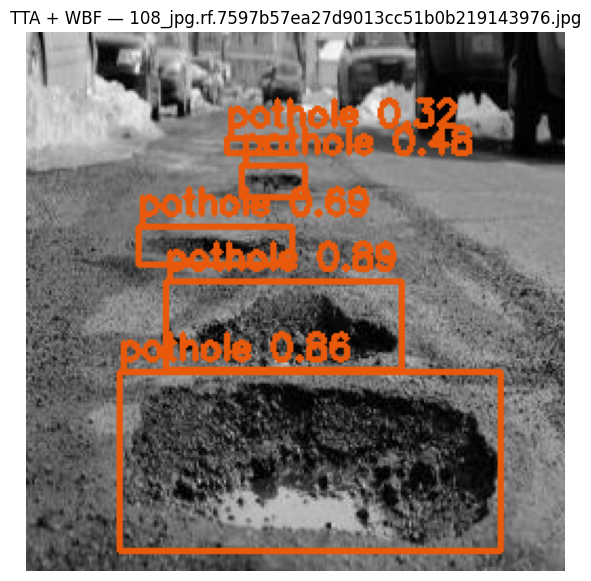

In [19]:
import cv2
from ensemble_boxes import weighted_boxes_fusion

def predict_normalized(model, image, conf, iou, use_tta):
    h, w = image.shape[:2]
    result = model.predict(image, conf=conf, iou=iou, augment=use_tta, verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy()
    boxes_norm = boxes.copy()
    boxes_norm[:, [0, 2]] /= w
    boxes_norm[:, [1, 3]] /= h
    return boxes_norm.tolist(), scores.tolist(), labels.tolist()


def run_tta_wbf(weight_paths, image_path, conf=0.20, iou_nms=0.6, wbf_iou_thr=0.55, use_tta=True):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    all_boxes, all_scores, all_labels = [], [], []
    for wp in weight_paths:
        m = YOLO(wp)
        b, s, l = predict_normalized(m, image, conf, iou_nms, use_tta)
        all_boxes.append(b); all_scores.append(s); all_labels.append(l)

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        all_boxes, all_scores, all_labels, iou_thr=wbf_iou_thr, skip_box_thr=0.0001
    )
    fused_boxes = np.array(fused_boxes)
    if len(fused_boxes):
        fused_boxes[:, [0, 2]] *= w
        fused_boxes[:, [1, 3]] *= h
    return fused_boxes, fused_scores, fused_labels, image


sample_image = image_paths[0]
fused_boxes, fused_scores, fused_labels, img = run_tta_wbf([BEST_WEIGHTS], sample_image, use_tta=True)

img_draw = img.copy()
for (x1, y1, x2, y2), sc, cl in zip(fused_boxes, fused_scores, fused_labels):
    p1, p2 = (int(x1), int(y1)), (int(x2), int(y2))
    cv2.rectangle(img_draw, p1, p2, (11, 89, 232), 2)
    cv2.putText(img_draw, f"{names[int(cl)]} {sc:.2f}", (p1[0], max(p1[1]-6, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (11, 89, 232), 2)

plt.figure(figsize=(9, 7))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"TTA + WBF — {sample_image.name}")
plt.savefig(RESULTS_DIR / "tta_wbf_sample.png", dpi=150, bbox_inches="tight")
plt.show()
